# QuPort benchmarking and topology sweeps

This notebook benchmarks random circuits, aggregates results, and sweeps topologies.

## Setup

In [1]:
import importlib.util
import subprocess
import sys

required = ['qiskit', 'matplotlib', 'pandas', 'numpy']
missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]
if missing:
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-q', '-e', '.[viz,yaml,graph]'
    ])
'ready'

'ready'

## Benchmark multiple circuits

In [2]:
from quport import MultiQPUConfig, LatencyModel
from quport.pipeline import benchmark_random_circuits

cfg = MultiQPUConfig(
    n_qpus=6,
    compute_qubits_per_qpu=5,
    comm_qubits_per_qpu=1,
    intra_topology='line',
    inter_topology='ring',
)
latency = LatencyModel()
rows = benchmark_random_circuits(
    cfg=cfg,
    n_logical=24,
    depth=10,
    trials=4,
    seed=3,
    latency=latency,
    strategies=('baseline', 'balanced', 'tpccap'),
)
len(rows)

12

## Aggregate results

In [3]:
import pandas as pd

df = pd.DataFrame(rows)
summary = df.groupby('strategy')[['swaps', 'remote_2q', 'cost_total']].mean().reset_index()
summary

,strategy,swaps,remote_2q,cost_total
0,balanced,0.0,119.75,37935.00
1,baseline,0.0,133.00,42071.25
2,tpccap,0.0,116.75,36744.75


## Visualize benchmark averages

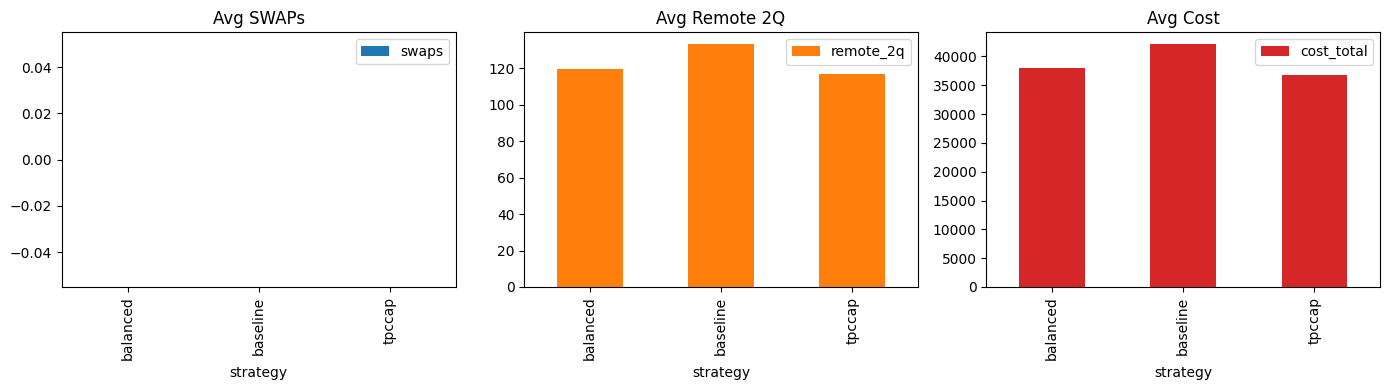

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
summary.plot.bar(x='strategy', y='swaps', ax=axes[0], color='tab:blue', title='Avg SWAPs')
summary.plot.bar(x='strategy', y='remote_2q', ax=axes[1], color='tab:orange', title='Avg Remote 2Q')
summary.plot.bar(x='strategy', y='cost_total', ax=axes[2], color='tab:red', title='Avg Cost')
plt.tight_layout()
plt.show()

## Sweep topologies and port counts

In [5]:
from quport.pipeline import sweep_topologies

sweep_topologies(
    n_logical=20,
    depth=8,
    trials=2,
    seed=11,
    out_csv='sweep.csv',
    intra_topologies=('clique', 'ring'),
    inter_topologies=('switch', 'ring', 'degree_d'),
    comm_ports=(1, 2),
    compute_per_qpu=5,
    n_qpus=6,
    inter_degree=2,
)
'sweep.csv written'

'sweep.csv written'

## Plot sweep results

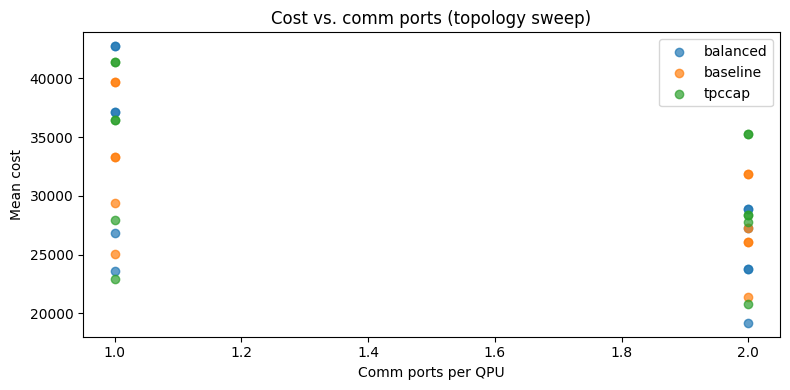

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

sweep = pd.read_csv('sweep.csv')
method_map = {0.0: 'baseline', 1.0: 'balanced', 2.0: 'tpccap'}
sweep['strategy'] = sweep['method'].map(method_map)

fig, ax = plt.subplots(figsize=(8, 4))
for strat, sub in sweep.groupby('strategy'):
    ax.scatter(sub['ports'], sub['cost_mean'], label=strat, alpha=0.7)
ax.set_title('Cost vs. comm ports (topology sweep)')
ax.set_xlabel('Comm ports per QPU')
ax.set_ylabel('Mean cost')
ax.legend()
plt.tight_layout()
plt.show()